## Cell 1 — Imports

In [2]:
%matplotlib inline
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

import czifile
from cellpose import models
from skimage import exposure, morphology
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops
from skimage.morphology import remove_small_objects, disk, binary_dilation
from skimage.segmentation import relabel_sequential


## Cell 2 — Parameters

In [ ]:
IMAGE_FOLDER   = r"D:\code"
#"1k_fed_day4"
#"1k_no_OA_day4"
#"3k_no_OA_no_chase_day3"
FILE_EXTENSION = "*.czi"
RESULTS_FOLDER = "Results"

SWAP_CHANNELS = True

USE_GPU            = True
CELLPOSE_DIAMETER  = 80 #Too high = merges cells; too low = splits cells

#cell-segmentation thresholds
FLOW_THRESH_BRIGHT = 0.4 #Lower = stricter, fewer false cells
PROB_THRESH_BRIGHT = -1.0 #More negative = accepts dimmer/weaker cells ADJUST THIS!!!
FLOW_THRESH_DIM    = 0.3
PROB_THRESH_DIM    = -6.0 #More negative = casts wider net for faint dim cells
CELL_MIN_AREA      = 300 #Lower = keeps smaller cells

#inclusion-detection parameters
INCLUSION_SELEM_RADIUS       = 20 # Larger = detects bigger spots
INCLUSION_CONTRAST_THRESHOLD = 0.008 # Lower = detects more/fainter inclusions
INCLUSION_MIN_BRIGHTNESS     = 0.04 #Lower = allows dimmer spots
MIN_INCLUSION_SIZE           = 20 #Lower = keeps tiny spots
INCLUSION_MIN_MEAN_INTENSITY = 0.005 # Mean brightness inside blob must exceed this — rejects faint diffuse blobs
MAX_INCLUSION_SIZE       = 600   # blobs larger than this are likely whole cells, not inclusions — increase if real inclusions are being cut off

# cell-aware inclusion filtering
INCLUSION_LOCAL_ZSCORE        = 1.5  # Higher = stricter within each cell
INCLUSION_LOCAL_PCTL          = 85   # Minimum within-cell percentile for candidate pixels

OUTPUT_FILENAME = "1k_OA_day3_PulseChaseAnalysisTH.csv"

os.makedirs(RESULTS_FOLDER, exist_ok=True)

#init cellpose 3 model (tries cyto3, falls back to cyto2 if download fails)
print("Initializing Cellpose 3 (cyto3)...")
try:
    model = models.Cellpose(gpu=USE_GPU, model_type='cyto3')
    print(f"  cyto3 ready  |  GPU={USE_GPU}")
except Exception as e:
    print(f"  cyto3 failed ({e}), falling back to cyto2")
    model = models.Cellpose(gpu=USE_GPU, model_type='cyto2')
print("Parameters set.")


Initializing Cellpose 3 (cyto3)...
  cyto3 ready  |  GPU=True
Parameters set.


## Cell 3 — Helper Functions

In [14]:
def normalize_image(image):
    """Min-max normalize to float64 [0, 1]."""
    img = image.astype(np.float64)
    mn, mx = img.min(), img.max()
    return np.zeros_like(img) if mx == mn else (img - mn) / (mx - mn)


def boost_contrast_visual(image):
    """Percentile stretch for DISPLAY ONLY."""
    p_lo, p_hi = np.percentile(image, (1, 99.5))
    return exposure.rescale_intensity(image, in_range=(p_lo, p_hi))


def load_channels(filepath):
    """Load .czi and return (green_raw, red_raw) as 2D arrays."""
    try:
        czi = czifile.CziFile(filepath)
        img = np.squeeze(czi.asarray())
    except Exception as e:
        print(f"  [ERROR] File load failed: {e}")
        return None, None

    ch0 = ch1 = None
    if img.ndim == 3 and img.shape[0] in (2, 3, 4):
        ch0, ch1 = img[0], img[1]
    elif img.ndim == 3 and img.shape[-1] in (2, 3, 4):
        ch0, ch1 = img[..., 0], img[..., 1]
    else:
        print(f"  [ERROR] Unexpected shape: {img.shape}")
        return None, None

    return (ch0, ch1) if SWAP_CHANNELS else (ch1, ch0)


# ── CELL SEGMENTATION — dual-pass Cellpose 3 ──────────────────────────────────
def segment_cells_single_pass(green_uint8):
    """
    Single-pass Cellpose 3 segmentation.

    This removes the bright/dim two-pass merge logic, which can introduce
    odd shapes and missed cells when the two passes disagree. The function
    runs Cellpose once on a gently normalized image and then applies only
    minimal cleanup.
    Returns a 2D integer label array (0=background, 1..N=cells).
    """
    if model is None:
        print("  [ERROR] Model not initialized.")
        return None

    img_norm = normalize_image(green_uint8).astype(np.float32)

    masks, _, _, _ = model.eval(
        img_norm,
        diameter=CELLPOSE_DIAMETER,
        channels=[0, 0],
        flow_threshold=FLOW_THRESH_BRIGHT,
        cellprob_threshold=PROB_THRESH_BRIGHT,
        do_3D=False,
        resample=True,
    )
    print(f"    Single pass:     {masks.max()} masks")

    cleaned = masks.copy().astype(np.int32)
    for rid in range(1, int(cleaned.max()) + 1):
        if (cleaned == rid).sum() < CELL_MIN_AREA:
            cleaned[cleaned == rid] = 0

    final, _, _ = relabel_sequential(cleaned)
    print(f"    Final cells:     {final.max()}")
    return final


# ── INCLUSION DETECTION — white top-hat ───────────────────────────────────────
def generate_inclusion_mask(green_norm, labeled_cells):
    """
    Cell-aware inclusion detection.

    Strategy:
      1) Use white top-hat to generate bright inclusion candidates.
      2) Restrict candidates to segmented cells.
      3) Within each cell, keep only pixels that are bright relative to that
         cell's own intensity distribution, which makes detection more robust
         when cells differ widely in baseline intensity.
      4) Apply the existing size / mean-intensity cleanup at the end.
    """
    selem = morphology.disk(INCLUSION_SELEM_RADIUS)
    spot_image = morphology.white_tophat(green_norm, selem)

    # Global candidate generation (kept similar to original behavior)
    candidate_mask = (
        (spot_image > INCLUSION_CONTRAST_THRESHOLD) &
        (green_norm > INCLUSION_MIN_BRIGHTNESS) &
        (labeled_cells > 0)
    )

    # Remove tiny speckles before per-cell filtering
    candidate_mask = remove_small_objects(candidate_mask, min_size=MIN_INCLUSION_SIZE)

    final_mask = np.zeros_like(candidate_mask, dtype=bool)

    # Cell-aware thresholding: compare each candidate pixel to its own cell's
    # local intensity distribution instead of a single image-wide threshold.
    for cid in range(1, int(labeled_cells.max()) + 1):
        cell_mask = labeled_cells == cid
        if not np.any(cell_mask):
            continue

        cell_vals = green_norm[cell_mask]
        if cell_vals.size == 0:
            continue

        cell_mean = float(cell_vals.mean())
        cell_std  = float(cell_vals.std())
        if cell_std == 0:
            cell_std = 1e-6

        local_thr = max(
            INCLUSION_MIN_BRIGHTNESS,
            cell_mean + INCLUSION_LOCAL_ZSCORE * cell_std,
            float(np.percentile(cell_vals, INCLUSION_LOCAL_PCTL))
        )

        keep = candidate_mask & cell_mask & (green_norm >= local_thr)
        final_mask[keep] = True

    # Clean up tiny speckles again after local filtering
    final_mask = remove_small_objects(final_mask, min_size=MIN_INCLUSION_SIZE)

    # Remove blobs too large to be inclusions (likely whole cells or debris)
    labeled_mask = label(final_mask)
    for prop in regionprops(labeled_mask):
        if prop.area > MAX_INCLUSION_SIZE:
            final_mask[labeled_mask == prop.label] = False

    # Remove blobs whose mean intensity is too low (faint / diffuse artefacts)
    labeled_mask = label(final_mask)
    for prop in regionprops(labeled_mask):
        blob_pixels = green_norm[labeled_mask == prop.label]
        if blob_pixels.mean() < INCLUSION_MIN_MEAN_INTENSITY:
            final_mask[labeled_mask == prop.label] = False

    return final_mask


def segment_lipids_otsu(red_channel):
    """Otsu-based lipid segmentation on normalized red channel."""
    red_norm = normalize_image(red_channel)
    try:
        otsu_val     = threshold_otsu(red_norm)
        final_thresh = max(otsu_val, 0.25)
    except Exception:
        final_thresh = 0.25
    binary_lipids = red_norm > final_thresh
    binary_lipids = remove_small_objects(binary_lipids, min_size=10)
    return binary_lipids  # boolean mask


def classify_inclusions_per_cell(labeled_cells, inclusion_mask, lipid_mask):
    """
    Per-cell inclusion classification.
    Any overlap with lipid mask → swiss cheese; otherwise → solid.

    Returns:
      cell_data : dict {cell_id: {type, cell_area, n_inclusions,
                                   n_solid_spots, n_swiss_spots,
                                   total_inclusion_area, lipid_area_in_cell}}
      vis_spots : dict {'solid': bool_mask, 'swiss': bool_mask}
    """
    dilated_lipids = binary_dilation(lipid_mask, footprint=disk(1))

    vis_solid = np.zeros_like(inclusion_mask, dtype=bool)
    vis_swiss = np.zeros_like(inclusion_mask, dtype=bool)
    cell_data = {}

    for cell_prop in regionprops(labeled_cells):
        cid       = cell_prop.label
        cell_mask = labeled_cells == cid

        inc_in_cell         = inclusion_mask & cell_mask
        labeled_inc_in_cell = label(inc_in_cell)
        inc_props           = regionprops(labeled_inc_in_cell)

        n_solid = n_swiss = total_inc_area = 0

        for inc in inc_props:
            r0, c0, r1, c1 = inc.bbox
            inc_blob  = (labeled_inc_in_cell[r0:r1, c0:c1] == inc.label)
            lipid_roi = dilated_lipids[r0:r1, c0:c1]
            total_inc_area += inc.area

            # any single overlapping pixel → swiss cheese
            if np.any(inc_blob & lipid_roi):
                n_swiss += 1
                vis_swiss[r0:r1, c0:c1][inc_blob] = True
            else:
                n_solid += 1
                vis_solid[r0:r1, c0:c1][inc_blob] = True

        if n_swiss > 0:
            cell_type = "swiss_cheese"
        elif n_solid > 0:
            cell_type = "solid"
        else:
            cell_type = "none"

        cell_data[cid] = {
            "type"                : cell_type,
            "cell_area"           : cell_prop.area,
            "n_inclusions"        : len(inc_props),
            "n_solid_spots"       : n_solid,
            "n_swiss_spots"       : n_swiss,
            "total_inclusion_area": total_inc_area,
            "lipid_area_in_cell"  : int(np.sum(cell_mask & lipid_mask)),
        }

    return cell_data, {"solid": vis_solid, "swiss": vis_swiss}


print("Helper functions defined.")


Helper functions defined.


## Cell 4 — Main Processing Loop

Found 2 file(s) in 'D:\code'
Processing: 1k_DOX_OA600_LTXDEEPRED_DAY4_1.czi
    Single pass:     68 masks
    Final cells:     64


C:\Users\elean\AppData\Local\Temp\ipykernel_5560\2862467177.py:97: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  candidate_mask = remove_small_objects(candidate_mask, min_size=MIN_INCLUSION_SIZE)
C:\Users\elean\AppData\Local\Temp\ipykernel_5560\2862467177.py:127: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  fina

    Inclusion pixels: 7,464


C:\Users\elean\AppData\Local\Temp\ipykernel_5560\2862467177.py:154: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary_lipids = remove_small_objects(binary_lipids, min_size=10)
C:\Users\elean\AppData\Local\Temp\ipykernel_5560\2862467177.py:169: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  dilated_lipids = binary_dilation(lipid_mask, footprint=disk(1))


    Lipid pixels:     215,002
SUMMARY: 1k_DOX_OA600_LTXDEEPRED_DAY4_1.czi
     Total cells            : 64
     Cells w/ solid incl.   : 11  (46 solid spots)
     Cells w/ swiss cheese  : 15  (30 swiss spots)
     Cells w/ no inclusions : 38


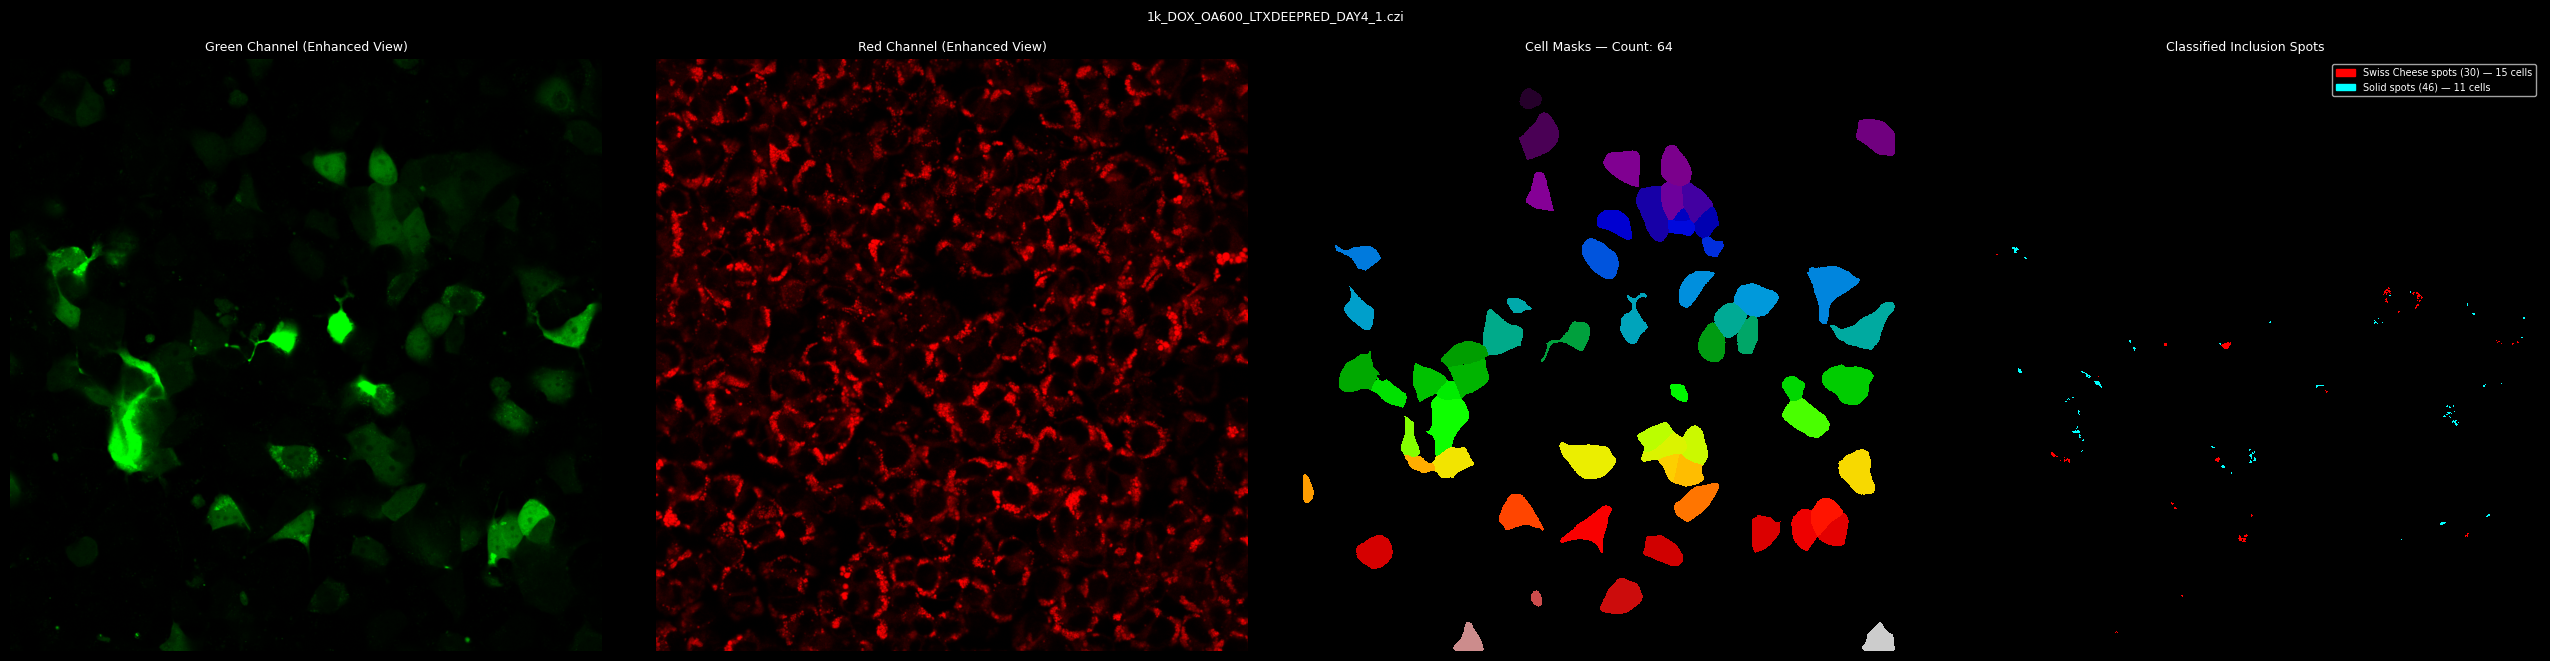

Processing: 1k_DOX_OA600_LTXDEEPRED_DAY4_2.czi
    Single pass:     93 masks
    Final cells:     76
    Inclusion pixels: 23,536
    Lipid pixels:     195,648
SUMMARY: 1k_DOX_OA600_LTXDEEPRED_DAY4_2.czi
     Total cells            : 76
     Cells w/ solid incl.   : 20  (96 solid spots)
     Cells w/ swiss cheese  : 39  (94 swiss spots)
     Cells w/ no inclusions : 17


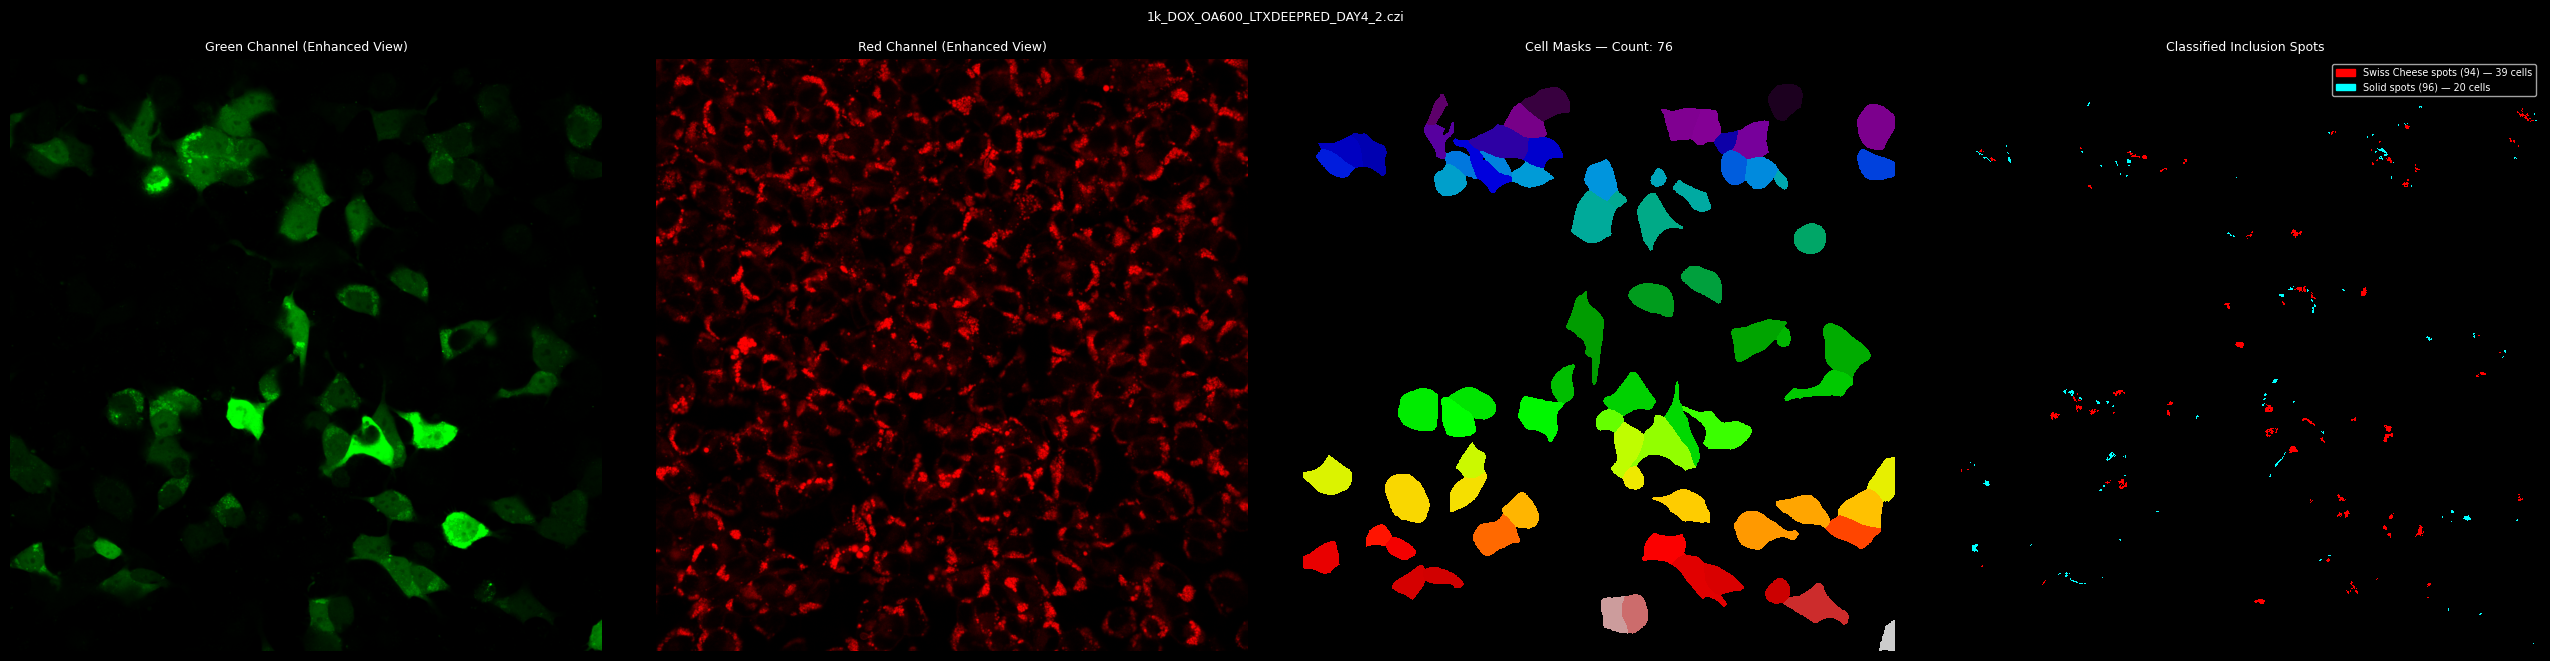

All files processed.
Total cells collected: 140


In [15]:
# color maps
cmap_green = LinearSegmentedColormap.from_list("G", [(0,0,0),(0,1,0)])
cmap_red   = LinearSegmentedColormap.from_list("R", [(0,0,0),(1,0,0)])

all_results = []

image_files = sorted(glob.glob(os.path.join(IMAGE_FOLDER, FILE_EXTENSION)))
print(f"Found {len(image_files)} file(s) in '{IMAGE_FOLDER}'")

for filepath in image_files:
    filename = os.path.basename(filepath)
    print(f"Processing: {filename}")

    # load channels
    green_raw, red_raw = load_channels(filepath)
    if green_raw is None:
        print("  Skipping (load error).")
        continue

    green_norm  = normalize_image(green_raw)
    green_uint8 = (green_norm * 255).astype(np.uint8)

    # dual-pass cell segmentation
    labeled_cells = segment_cells_single_pass(green_uint8)
    if labeled_cells is None or labeled_cells.max() == 0:
        print("  No cells found, skipping.")
        continue

    # detect inclusions
    inclusion_mask = generate_inclusion_mask(green_norm, labeled_cells)
    print(f"    Inclusion pixels: {inclusion_mask.sum():,}")

    # segment lipids
    lipid_mask = segment_lipids_otsu(red_raw)
    print(f"    Lipid pixels:     {lipid_mask.sum():,}")

    # classify inclusions
    cell_data, vis_spots = classify_inclusions_per_cell(
        labeled_cells, inclusion_mask, lipid_mask
    )

    # summary
    n_cells           = labeled_cells.max()
    n_swiss           = sum(1 for v in cell_data.values() if v["type"] == "swiss_cheese")
    n_solid           = sum(1 for v in cell_data.values() if v["type"] == "solid")
    n_none            = sum(1 for v in cell_data.values() if v["type"] == "none")
    total_swiss_spots = sum(v["n_swiss_spots"] for v in cell_data.values())
    total_solid_spots = sum(v["n_solid_spots"] for v in cell_data.values())

    print(f"SUMMARY: {filename}")
    print(f"     Total cells            : {n_cells}")
    print(f"     Cells w/ solid incl.   : {n_solid}  ({total_solid_spots} solid spots)")
    print(f"     Cells w/ swiss cheese  : {n_swiss}  ({total_swiss_spots} swiss spots)")
    print(f"     Cells w/ no inclusions : {n_none}") 

    # visualization
    H, W           = labeled_cells.shape
    cell_display   = np.where(labeled_cells > 0, labeled_cells, np.nan)
    vis_solid_mask = vis_spots["solid"]
    vis_swiss_mask = vis_spots["swiss"]

    fig, axes = plt.subplots(1, 4, figsize=(26, 6.5))
    fig.patch.set_facecolor("black")
    fig.suptitle(filename, color="white", fontsize=9, y=1.01)

    axes[0].imshow(boost_contrast_visual(green_raw), cmap=cmap_green)
    axes[0].set_title("Green Channel (Enhanced View)", color="white", fontsize=9)

    axes[1].imshow(boost_contrast_visual(red_raw), cmap=cmap_red)
    axes[1].set_title("Red Channel (Enhanced View)", color="white", fontsize=9)

    axes[2].set_facecolor("black")
    axes[2].imshow(cell_display, cmap="nipy_spectral", interpolation="none", vmin=1)
    axes[2].set_title(f"Cell Masks — Count: {n_cells}", color="white", fontsize=9)

    axes[3].set_facecolor("black")
    axes[3].imshow(np.zeros((H, W)), cmap="gray", vmin=0, vmax=1)
    if vis_solid_mask.any():
        axes[3].imshow(
            np.ma.masked_where(~vis_solid_mask, np.ones((H, W))),
            cmap=ListedColormap(["cyan"]), alpha=1.0, interpolation="none"
        )
    if vis_swiss_mask.any():
        axes[3].imshow(
            np.ma.masked_where(~vis_swiss_mask, np.ones((H, W))),
            cmap=ListedColormap(["red"]), alpha=1.0, interpolation="none"
        )

    legend_patches = [
        mpatches.Patch(color="red",  label=f"Swiss Cheese spots ({total_swiss_spots}) — {n_swiss} cells"),
        mpatches.Patch(color="cyan", label=f"Solid spots ({total_solid_spots}) — {n_solid} cells"),
    ]
    axes[3].legend(handles=legend_patches, loc="upper right",
                   fontsize="x-small", facecolor="black", labelcolor="white")
    axes[3].set_title("Classified Inclusion Spots", color="white", fontsize=9)

    for ax in axes:
        ax.axis("off")
        ax.set_facecolor("black")

    plt.tight_layout()
    plt.show()

    # collect per-cell rows for output
    for cid, info in cell_data.items():
        cell_mask = (labeled_cells == cid)
        if np.any(cell_mask):
            avg_pixel_mfi = float(np.mean(green_raw[cell_mask]))
        else:
            avg_pixel_mfi = np.nan
        all_results.append({
            "Filename"               : filename,
            "Cell_ID"                : cid,
            "Cell_Type"              : info["type"],
            "Cell_Area_px"           : info["cell_area"],
            "Inclusion_Count"        : info["n_inclusions"],
            "Solid_Inclusion_Spots"  : info["n_solid_spots"],
            "Swiss_Inclusion_Spots"  : info["n_swiss_spots"],
            "Total_Inclusion_Area_px": info["total_inclusion_area"],
            "Avg_Inclusion_Size_px"  : round(info["total_inclusion_area"] / info["n_inclusions"], 2)
                                        if info["n_inclusions"] > 0 else 0,
            "Lipid_Surface_Area_px"  : info["lipid_area_in_cell"],
            "Is_SwissCheese"         : int(info["type"] == "swiss_cheese"),
            "Is_SolidInclusion"      : int(info["type"] == "solid"),
            "Has_AnyInclusion"       : int(info["type"] != "none"),
            "Avg_Pixel_MFI_Cell"    : avg_pixel_mfi,
        })

print("All files processed.")
print(f"Total cells collected: {len(all_results)}")


## Cell 5 — Save Results to CSV

In [6]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

if not all_results:
    print("No results to save.")
else:
    df = pd.DataFrame(all_results)

    # Keep ONLY columns actually used
    summary = pd.DataFrame({
        "Image Name": df["Filename"],
        "Cell ID": df["Cell_ID"],
        "Swiss Cheese Inclusions": df["Swiss_Inclusion_Spots"],
        "Solid Inclusions": df["Solid_Inclusion_Spots"],
        "Lipid Droplet Area (px)": df["Lipid_Surface_Area_px"],
        "Cytoplasm Area (px)": df["Cell_Area_px"],
        "Avg Pixel MFI Cell": df["Avg_Pixel_MFI_Cell"],  # <-- your new metric
    })

    wb = openpyxl.Workbook()
    ws = wb.active
    ws.title = "Pulse Chase Per Cell"

    headers = list(summary.columns)

    header_fill  = PatternFill("solid", start_color="1F4E79")
    header_font  = Font(bold=True, color="FFFFFF", name="Arial", size=11)
    center_align = Alignment(horizontal="center", vertical="center")
    left_align   = Alignment(horizontal="left", vertical="center")

    thin_border = Border(
        bottom=Side(style="thin", color="AAAAAA"),
        right=Side(style="thin", color="AAAAAA")
    )

    # Header row
    for col_idx, h in enumerate(headers, 1):
        cell = ws.cell(row=1, column=col_idx, value=h)
        cell.font = header_font
        cell.fill = header_fill
        cell.alignment = center_align
        cell.border = thin_border

    ws.row_dimensions[1].height = 34

    alt_fill = PatternFill("solid", start_color="D6E4F0")

    # Data rows
    for r_idx, row in enumerate(summary.itertuples(index=False), start=2):
        fill = alt_fill if r_idx % 2 == 0 else None

        for c_idx, val in enumerate(row, start=1):
            cell = ws.cell(row=r_idx, column=c_idx, value=val)
            if fill:
                cell.fill = fill
            cell.border = thin_border
            cell.font = Font(name="Arial", size=10)
            cell.alignment = left_align if c_idx == 1 else center_align

    # Adjust widths to match new columns
    widths = [40, 10, 24, 18, 24, 22, 22]
    for i, w in enumerate(widths, 1):
        ws.column_dimensions[get_column_letter(i)].width = w

    ws.freeze_panes = "A2"

    # Save directly as XLSX
    xlsx_path = os.path.join(RESULTS_FOLDER, OUTPUT_FILENAME.replace(".csv", ".xlsx"))
    wb.save(xlsx_path)

    print(f"Saved → {xlsx_path}")

Saved → Results\1k_OA_day3_PulseChaseAnalysisTH.xlsx
